In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" Bibliothèques importées avec succès")

 Bibliothèques importées avec succès


In [2]:
df = pd.read_csv('../data/raw/dataset_ProjetML_2026.csv')

In [3]:
print(f"Shape : {df.shape}")

Shape : (10500, 9)


In [7]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [8]:
print("=== INFORMATIONS GENERALES ===")
print(df.info())

=== INFORMATIONS GENERALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB
None


In [9]:
print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== STATISTIQUES DESCRIPTIVES ===


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


In [4]:
print("Doublons :", df.duplicated().sum())

Doublons : 776


In [5]:
df = df.drop_duplicates()

In [6]:
print("Après suppression :", df.shape)


Après suppression : (9724, 9)


In [7]:
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage (%)': missing_pct
})
print(missing_df)

=== VALEURS MANQUANTES ===
                  Manquants  Pourcentage (%)
Poids                   974            10.02
Volume                  537             5.52
Conductivite            972            10.00
Opacite                 989            10.17
Rigidite                554             5.70
Prix_Revente            533             5.48
Categorie               511             5.26
Source                  535             5.50
Rapport_Collecte          0             0.00


=== DISTRIBUTION DE LA CIBLE ===
Categorie
Plastique    2562
Verre        2384
Métal        2163
Papier       2104
NaN           511
Name: count, dtype: int64


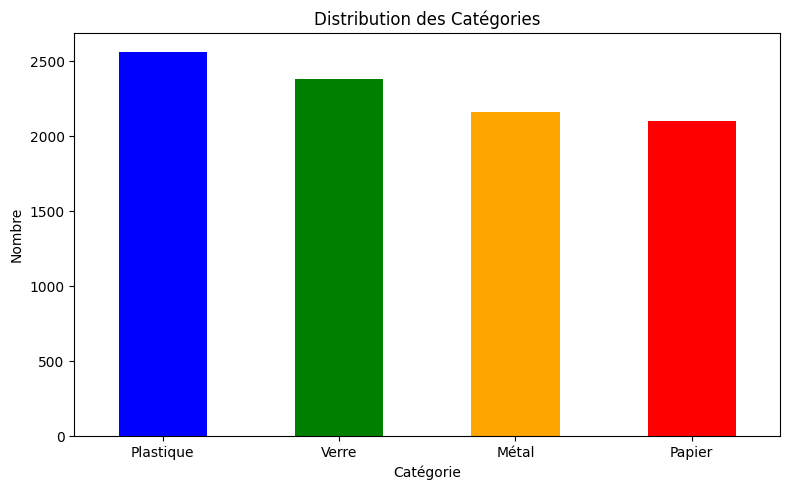

In [8]:
print("=== DISTRIBUTION DE LA CIBLE ===")
print(df['Categorie'].value_counts(dropna=False))

plt.figure(figsize=(8,5))
df['Categorie'].value_counts().plot(kind='bar', color=['blue','green','orange','red'])
plt.title('Distribution des Catégories')
plt.xlabel('Catégorie')
plt.ylabel('Nombre')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

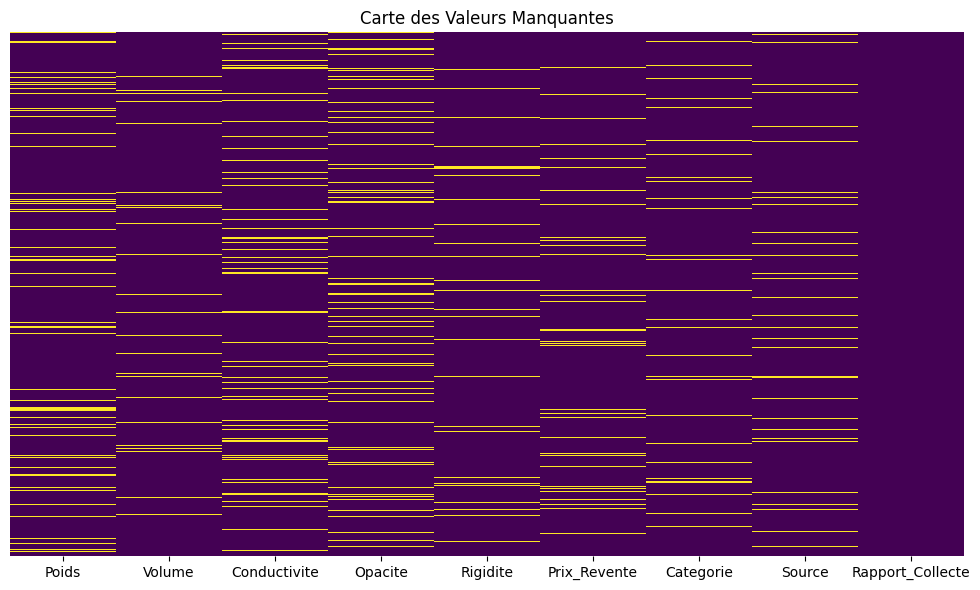

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Carte des Valeurs Manquantes')
plt.tight_layout()
plt.show()

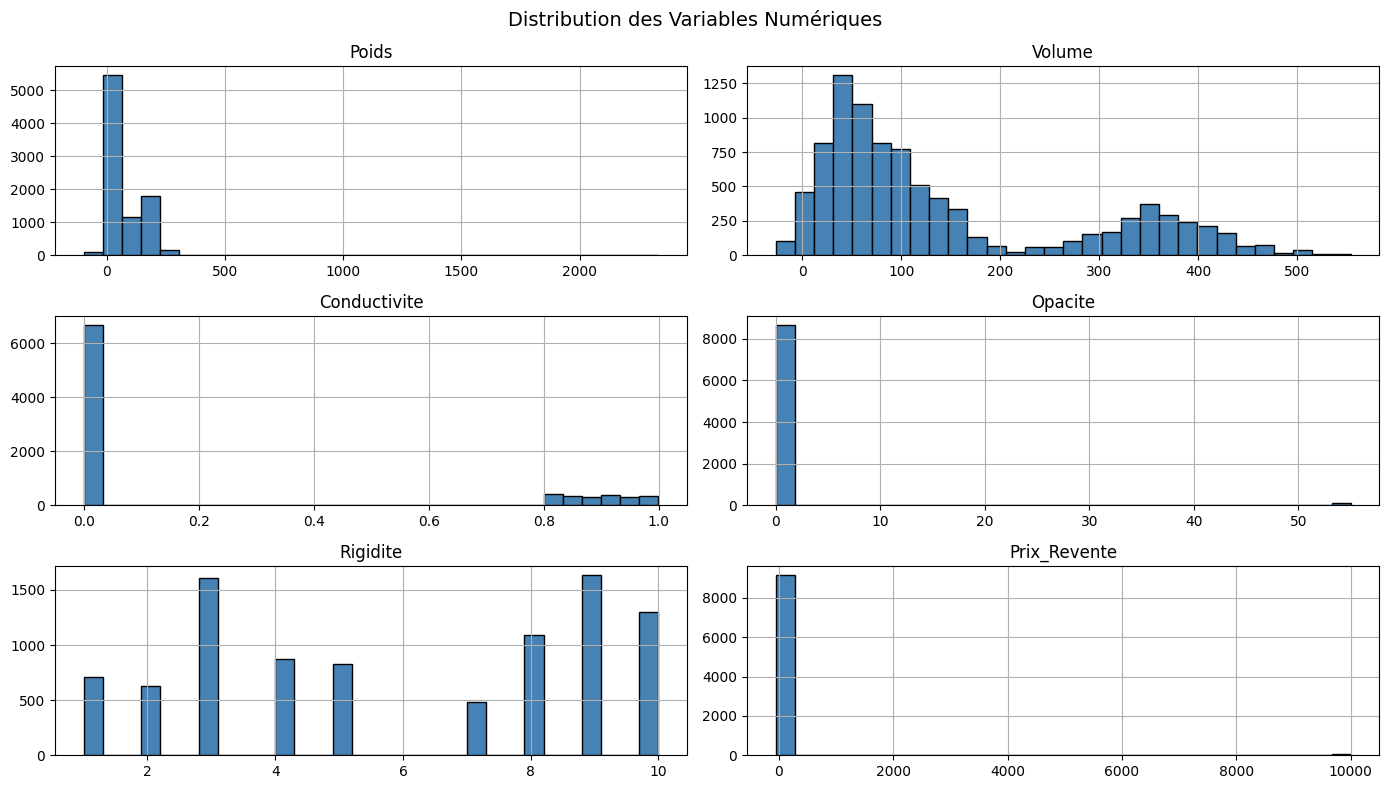

In [10]:
cols_numeriques = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

df[cols_numeriques].hist(figsize=(14,8), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution des Variables Numériques', fontsize=14)
plt.tight_layout()
plt.show()

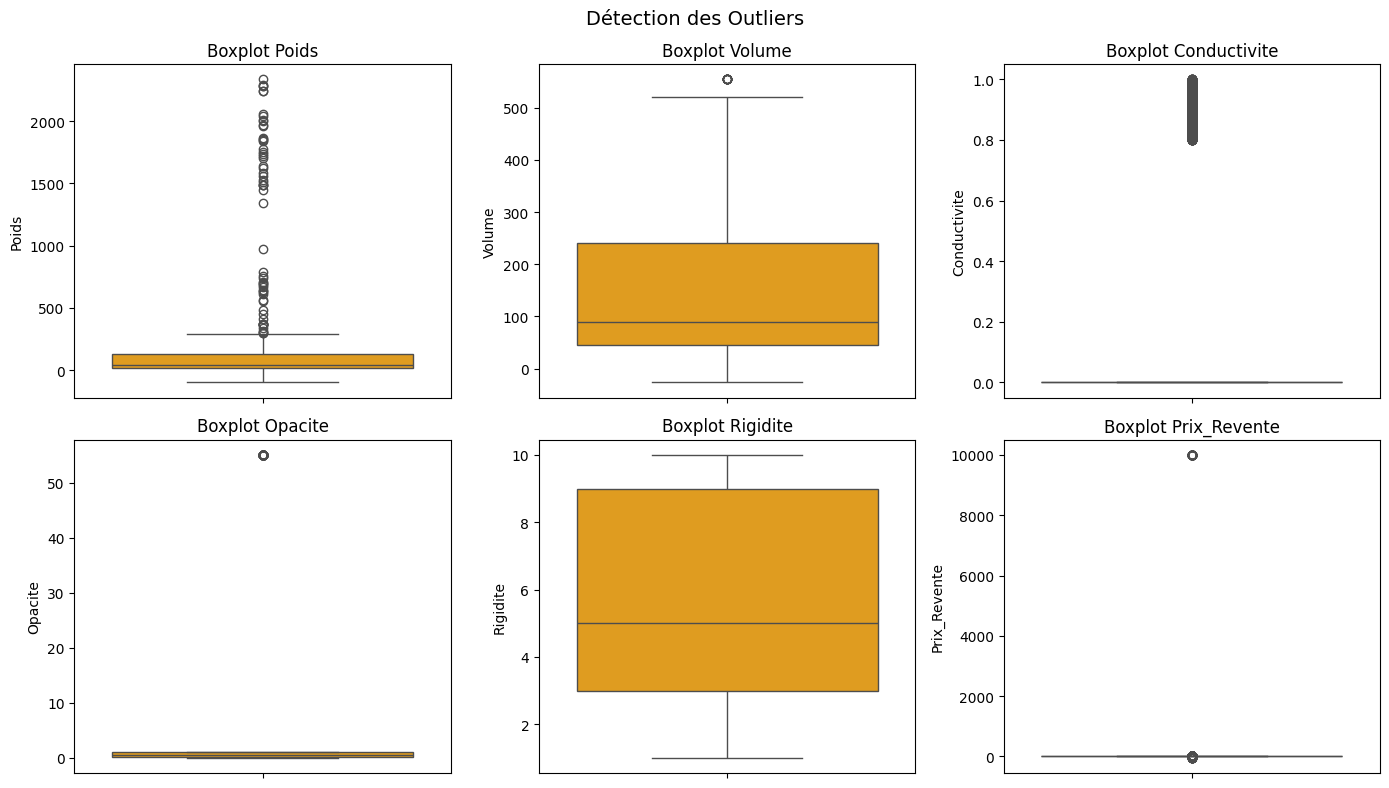

In [17]:
plt.figure(figsize=(14,8))
for i, col in enumerate(cols_numeriques):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='orange')
    plt.title(f'Boxplot {col}')
plt.suptitle('Détection des Outliers', fontsize=14)
plt.tight_layout()
plt.show()

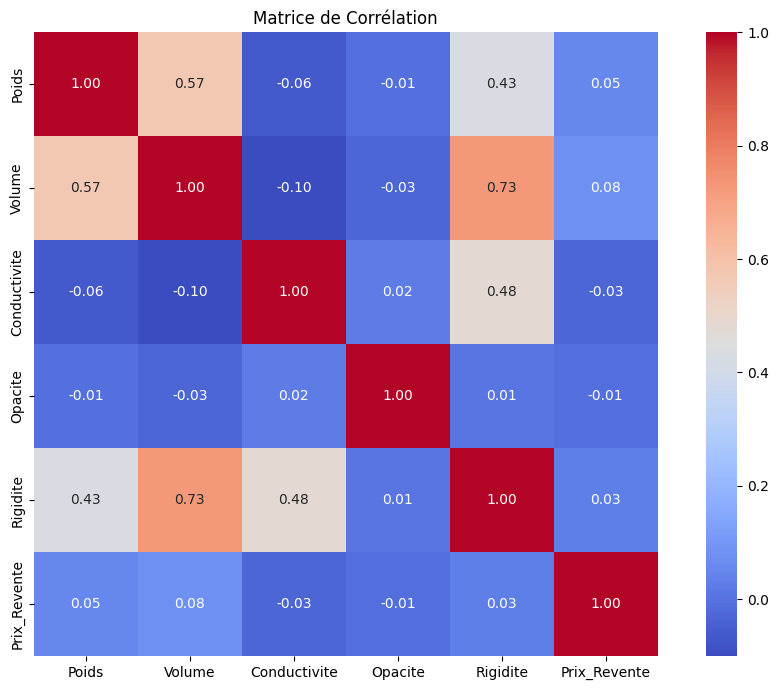

In [18]:
plt.figure(figsize=(10,7))
corr = df[cols_numeriques].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()

In [11]:
print("=== AVANT NETTOYAGE ===")
print(f"Lignes : {len(df)}")
print(f"Poids min : {df['Poids'].min()}")
print(f"Volume min : {df['Volume'].min()}")
print(f"Prix_Revente max : {df['Prix_Revente'].max()}")

# Supprimer valeurs impossibles
df = df[df['Poids'] > 0]        # Poids négatif impossible
df = df[df['Volume'] > 0]       # Volume négatif impossible
df = df[df['Prix_Revente'] >= 0] # Prix négatif impossible

print("\n=== APRES NETTOYAGE BASIQUE ===")
print(f"Lignes restantes : {len(df)}")

=== AVANT NETTOYAGE ===
Lignes : 9724
Poids min : -99.0
Volume min : -26.80771241307457
Prix_Revente max : 9999.0

=== APRES NETTOYAGE BASIQUE ===
Lignes restantes : 7527


In [13]:
# === TRAITEMENT DES OUTLIERS PAR WINSORISATION (IQR) ===
# On ne supprime PAS les outliers : on les cape aux bornes IQR
# Cela préserve toutes les lignes tout en limitant l'influence des valeurs extrêmes

def capper_outliers_iqr(df, colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 3 * IQR
    borne_sup = Q3 + 3 * IQR
    nb_outliers = ((df[colonne] < borne_inf) | (df[colonne] > borne_sup)).sum()
    df[colonne] = df[colonne].clip(lower=borne_inf, upper=borne_sup)
    print(f"{colonne} : {nb_outliers} outliers cappés (borne_inf={borne_inf:.2f}, borne_sup={borne_sup:.2f})")
    return df

for col in ['Poids', 'Volume', 'Prix_Revente']:
    df = capper_outliers_iqr(df, col)

print(f"Lignes conservées : {len(df)}  (aucune ligne supprimée)")


Poids : 43 outliers cappés (borne_inf=-334.73, borne_sup=496.73)
Volume : 0 outliers cappés (borne_inf=-597.34, borne_sup=907.53)
Prix_Revente : 306 outliers cappés (borne_inf=-14.27, borne_sup=23.20)
Lignes conservées : 7527  (aucune ligne supprimée)


=== VÉRIFICATION DES OUTLIERS APRÈS CAPPING ===

Poids                | borne_inf=-334.73  borne_sup=496.73 | ✅ OK
Volume               | borne_inf=-597.34  borne_sup=907.53 | ✅ OK
Prix_Revente         | borne_inf=-14.27  borne_sup=23.20 | ✅ OK

✅ Aucun outlier hors bornes — winsorisation correctement appliquée.


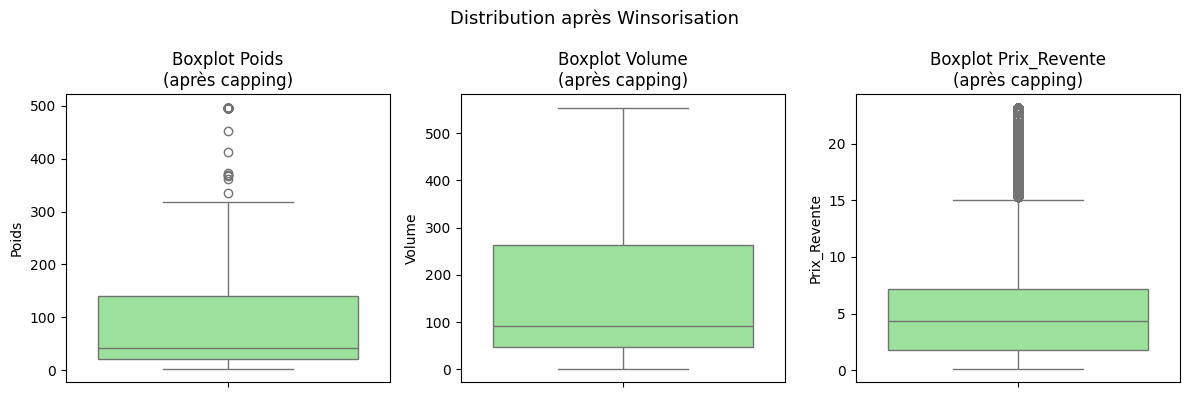

In [15]:
# === VÉRIFICATION POST-WINSORISATION ===

print("=== VÉRIFICATION DES OUTLIERS APRÈS CAPPING ===\n")

cols_verif = ['Poids', 'Volume', 'Prix_Revente']

tout_ok = True
for col in cols_verif:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 3 * IQR
    borne_sup = Q3 + 3 * IQR

    nb_outliers = ((df[col] < borne_inf) | (df[col] > borne_sup)).sum()
    statut = "✅ OK" if nb_outliers == 0 else f"⚠️  {nb_outliers} outliers restants"
    print(f"{col:20s} | borne_inf={borne_inf:.2f}  borne_sup={borne_sup:.2f} | {statut}")
    
    if nb_outliers > 0:
        tout_ok = False

print()
if tout_ok:
    print("✅ Aucun outlier hors bornes — winsorisation correctement appliquée.")
else:
    print("⚠️  Des outliers subsistent — vérifier la fonction capper_outliers_iqr.")

# Visualisation boxplots après capping
plt.figure(figsize=(12, 4))
for i, col in enumerate(cols_verif):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot {col}\n(après capping)')
plt.suptitle('Distribution après Winsorisation', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# === DIAGNOSTIC TYPE DE MANQUANT ===
df['Poids_missing'] = df['Poids'].isnull().astype(int)

print("=== DIAGNOSTIC MCAR/MAR ===")
print(df.groupby('Poids_missing')[['Volume', 'Rigidite', 'Conductivite']].mean().round(3))
print("\n→ Moyennes différentes = MAR → KNN")
print("→ Moyennes similaires  = MCAR → Médiane")

df.drop(columns=['Poids_missing'], inplace=True)

=== DIAGNOSTIC MCAR/MAR ===
                Volume  Rigidite  Conductivite
Poids_missing                                 
0              150.015     6.022         0.216

→ Moyennes différentes = MAR → KNN
→ Moyennes similaires  = MCAR → Médiane


In [17]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols_numeriques = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

print("=== VALEURS MANQUANTES AVANT IMPUTATION ===")
print(df[cols_numeriques].isnull().sum())

=== VALEURS MANQUANTES AVANT IMPUTATION ===
Poids             0
Volume            0
Conductivite    767
Opacite         754
Rigidite        425
Prix_Revente      0
dtype: int64


In [18]:
# === COMPARAISON MÉDIANE vs KNN vs ITERATIVE ===
cols_numeriques = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

for nom, imp in [
    ('Médiane',   SimpleImputer(strategy='median')),
    ('KNN',       KNNImputer(n_neighbors=5)),
    ('Iterative', IterativeImputer(max_iter=10, random_state=42))
]:
    df_tmp = pd.DataFrame(
        imp.fit_transform(df[cols_numeriques]),
        columns=cols_numeriques
    )
    print(f"\n--- {nom} ---")
    print(df_tmp[['Poids', 'Volume', 'Rigidite']].describe().loc[['mean', 'std', '50%']].round(3))

print("\n Choix retenu :")
print("   → KNN     pour Poids, Volume, Rigidite   (MAR — corrélées)")
print("   → Médiane pour Conductivite, Opacite     (MCAR — indépendantes)")


--- Médiane ---
       Poids   Volume  Rigidite
mean  77.116  150.015     6.077
std   76.155  136.444     3.011
50%   42.277   92.099     7.000

--- KNN ---
       Poids   Volume  Rigidite
mean  77.116  150.015     6.029
std   76.155  136.444     3.093
50%   42.277   92.099     7.000

--- Iterative ---
       Poids   Volume  Rigidite
mean  77.116  150.015     6.030
std   76.155  136.444     3.081
50%   42.277   92.099     7.000

 Choix retenu :
   → KNN     pour Poids, Volume, Rigidite   (MAR — corrélées)
   → Médiane pour Conductivite, Opacite     (MCAR — indépendantes)


In [19]:
# Imputation par colonne selon le type de manquant

df_correct = df.copy()

# Colonnes MAR → KNN (corrélées entre elles)
cols_knn = ['Poids', 'Volume', 'Rigidite']
imputer_knn = KNNImputer(n_neighbors=5)
df_correct[cols_knn] = imputer_knn.fit_transform(df_correct[cols_knn])

# Colonnes MCAR → Médiane
cols_mediane = ['Conductivite', 'Opacite', 'Prix_Revente']
imputer_mediane = SimpleImputer(strategy='median')
df_correct[cols_mediane] = imputer_mediane.fit_transform(df_correct[cols_mediane])

# Source → Mode (catégorielle)
df_correct['Source'].fillna(df_correct['Source'].mode()[0], inplace=True)

print("=== VERIFICATION APRES IMPUTATION ===")
print(df_correct.isnull().sum())
print(f"\n  Imputation par colonne terminée")
print(f"Shape : {df_correct.shape}")

=== VERIFICATION APRES IMPUTATION ===
Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           404
Source                0
Rapport_Collecte      0
dtype: int64

  Imputation par colonne terminée
Shape : (7527, 9)


In [20]:

df_clean = df_correct.copy()

# on garde les NaN pour l'instant (semi-supervisé plus tard)
print("=== VERIFICATION FINALE APRES IMPUTATION ===")
print(df_clean.isnull().sum())
print(f"\n  Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")


=== VERIFICATION FINALE APRES IMPUTATION ===
Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           404
Source                0
Rapport_Collecte      0
dtype: int64

  Valeurs manquantes restantes : 404


In [21]:
from sklearn.preprocessing import LabelEncoder

# Encoder Source
le_source = LabelEncoder()
df_clean['Source_encoded'] = le_source.fit_transform(df_clean['Source'])

# Encoder Categorie (seulement les lignes non-NaN)
le_categorie = LabelEncoder()
mask = df_clean['Categorie'].notna()
df_clean.loc[mask, 'Categorie_encoded'] = le_categorie.fit_transform(df_clean.loc[mask, 'Categorie'])

print("=== ENCODAGE ===")
print("Source :", le_source.classes_)
print("Categorie :", le_categorie.classes_)
print(df_clean[['Source', 'Source_encoded', 'Categorie', 'Categorie_encoded']].head(8))

=== ENCODAGE ===
Source : ['Centre_Tri' 'Collecte_Citoyenne' 'Usine_A' 'Usine_B']
Categorie : ['Métal' 'Papier' 'Plastique' 'Verre']
                Source  Source_encoded  Categorie  Categorie_encoded
0   Collecte_Citoyenne               1     Papier                1.0
1              Usine_A               2  Plastique                2.0
5              Usine_B               3  Plastique                2.0
6   Collecte_Citoyenne               1      Verre                3.0
7   Collecte_Citoyenne               1      Verre                3.0
8              Usine_A               2     Papier                1.0
9           Centre_Tri               0      Métal                0.0
10  Collecte_Citoyenne               1     Papier                1.0


In [22]:
from sklearn.preprocessing import StandardScaler

cols_a_normaliser = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']

scaler = StandardScaler()
df_clean[cols_a_normaliser] = scaler.fit_transform(df_clean[cols_a_normaliser])

print("=== APRES NORMALISATION ===")
print(df_clean[cols_a_normaliser].describe().round(2))

=== APRES NORMALISATION ===
         Poids   Volume  Conductivite  Opacite  Rigidite
count  7527.00  7527.00       7527.00  7527.00   7527.00
mean     -0.00    -0.00          0.00    -0.00      0.00
std       1.00     1.00          1.00     1.00      1.00
min      -0.99    -1.10         -0.52    -0.21     -1.63
25%      -0.73    -0.75         -0.52    -0.17     -0.98
50%      -0.46    -0.42         -0.52    -0.10      0.31
75%       0.83     0.83         -0.52    -0.02      0.96
max       5.51     2.96          2.18    10.30      1.28


In [23]:
# sauvegarde du dataset + scaler + encodeurs
import os
import joblib

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Sauvegarder le dataset nettoyé
df_clean.to_csv('../data/processed/dataset_clean.csv', index=False)

# Sauvegarder le scaler et les encodeurs (nécessaire pour les prédictions futures)
joblib.dump(scaler,       '../models/scaler.pkl')
joblib.dump(le_source,    '../models/le_source.pkl')
joblib.dump(le_categorie, '../models/le_categorie.pkl')

print(" Dataset nettoyé sauvegardé !")
print(" Scaler et encodeurs sauvegardés dans /models/")
print(f"Shape final : {df_clean.shape}")

 Dataset nettoyé sauvegardé !
 Scaler et encodeurs sauvegardés dans /models/
Shape final : (7527, 11)
